In [39]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd 
from sklearn.model_selection import train_test_split

In [40]:
insurance_data=pd.read_csv("insurance.csv")
X = insurance_data.drop(columns=["charges"])
y = insurance_data["charges"]

X= pd.get_dummies(X,columns=["region"], drop_first=True,dtype=int)

X["sex"]=X["sex"].map({"male": 0 , "female" : 1})
X["smoker"]=X["smoker"].map({"no": 0 , "yes" : 1})

X["age_smoker"]=X["age"]*X["smoker"]
X["bmi_smoker"]=X["bmi"]*X["smoker"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

MSE for a aplha=0.001: 20922599.87103596
MSE for a aplha=0.1: 20921803.698431373
MSE for a aplha=1: 20914832.63508914
MSE for a aplha=2: 20908106.77995452
MSE for a aplha=3: 20901927.931570217
MSE for a aplha=4: 20896130.81113565
MSE for a aplha=5: 20890881.000633497
MSE for a aplha=10: 20872844.794796687
MSE for a aplha=20: 20877828.532378826
MSE for a aplha=30.4: 20941063.014556676
MSE for a aplha=50: 21196929.86960891
MSE for a aplha=100: 22423172.686023246


<Axes: >

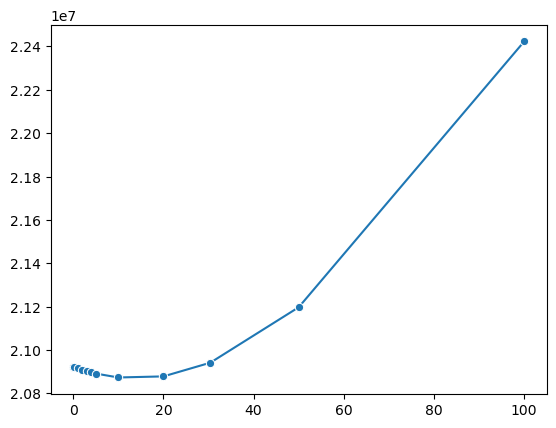

In [41]:
import seaborn as sns 
alphas =[0.001,0.1,1,2,3,4,5,10,20,30.40,50,100]
mses =  []
for a in alphas:
    lasso_model= Lasso(alpha=a)
    lasso_model.fit(X_train,y_train)
    
    y_pred = lasso_model.predict(X_test)
    mse = mean_squared_error(y_test ,y_pred)
    print(f"MSE for a aplha={a}:", mse)
    mses.append(mse)

sns.lineplot(x=alphas,y=mses ,marker ="o")

In [43]:
from sklearn.linear_model import LassoCV
a =[0.001,0.1,1,2,3,4,5,10,20,30.40,50,100]
lasso_cv_model = LassoCV(
    alphas = a,
    cv = 5,
    max_iter= 1000,
    random_state= 42
)

lasso_cv_model.fit(X_train, y_train)

print("best alpha: ", lasso_cv_model.alpha_)

y_pred = lasso_cv_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("mse = ", mse)
print("s2 = ", r2)

best alpha:  0.001
mse =  20922599.87103596
s2 =  0.8652317499151699
